In [25]:
import numpy as np
import trimesh
import open3d as o3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [26]:
source_filepath = 'data/surfaces/igea-compare/igea-deg2-not-trunc.ply'
target_filepath = 'data/surfaces/igea-compare/target.off'

#source_filepath = 'data/surfaces/bob500-inv-exp-compare/gausscurv.ply'
#target_filepath = 'data/surfaces/bob500-inv-exp-compare/bob.obj'

#source_filepath = 'data/surfaces/fertility500-inv-exp/fertility-inv-exp.ply'
#target_filepath = 'data/surfaces/fertility500-inv-exp/fertility-target.ply'


source_mesh = trimesh.load( source_filepath, process=False)
target_mesh = trimesh.load( target_filepath, process=False)


# Normalize target to a [-0.9, 0.9] bounding box: center on its bbox
# center, then uniformly scale so the largest bbox dimension spans
# [-0.9, 0.9].
target_verts = np.asarray(target_mesh.vertices)
bbox_min = np.min(target_verts, axis=0)
bbox_max = np.max(target_verts, axis=0)
center = (bbox_min + bbox_max) / 2
scale = 1.8 / np.max(bbox_max - bbox_min)
target_mesh.vertices = (target_verts - center) * scale

In [27]:
# Centroid of every source triangle
source_centroids = source_mesh.triangles_center.astype(np.float32)  # (F_src, 3)

# For each centroid, find the closest point on the target mesh surface
# and which target triangle it lies on. Uses open3d's Embree-backed
# RaycastingScene instead of trimesh.proximity.closest_point, which does
# an unvectorized Python-level loop per query point and is much slower
# at this point count.
scene = o3d.t.geometry.RaycastingScene()
target_t = o3d.t.geometry.TriangleMesh(
    o3d.core.Tensor(np.asarray(target_mesh.vertices), dtype=o3d.core.Dtype.Float32),
    o3d.core.Tensor(np.asarray(target_mesh.faces), dtype=o3d.core.Dtype.UInt32),
)
scene.add_triangles(target_t)

result = scene.compute_closest_points(o3d.core.Tensor(source_centroids, dtype=o3d.core.Dtype.Float32))
target_face_ids = result['primitive_ids'].numpy().astype(np.int64)

source_normals = source_mesh.face_normals               # (F_src, 3)
target_normals = target_mesh.face_normals[target_face_ids]  # (F_src, 3), matched per source face

dots = np.einsum('ij,ij->i', source_normals, target_normals)

flipped_mask = dots < 0
n_flipped = np.sum(flipped_mask)
print(f"{n_flipped} / {len(dots)} source faces ({100 * n_flipped / len(dots):.2f}%) "
      f"have a flipped normal relative to the nearest target face")

# Same proportion but weighted by triangle area, so a handful of large
# flipped triangles counts for more than many tiny ones (and vice versa).
face_areas = source_mesh.area_faces
area_weighted_flipped = np.sum(face_areas[flipped_mask]) / np.sum(face_areas)
print(f"{100 * area_weighted_flipped:.2f}% of source surface area "
      f"has a flipped normal relative to the nearest target face")

13065 / 2048000 source faces (0.64%) have a flipped normal relative to the nearest target face
0.15% of source surface area has a flipped normal relative to the nearest target face


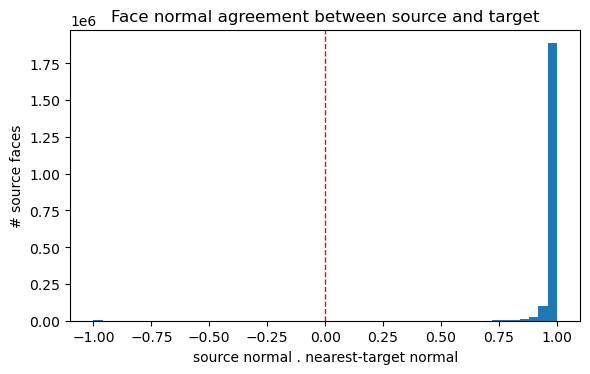

In [28]:
# Histogram of the normal-dot-products
plt.figure(figsize=(6, 4))
plt.hist(dots, bins=50, range=(-1, 1))
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('source normal . nearest-target normal')
plt.ylabel('# source faces')
plt.title('Face normal agreement between source and target')
plt.tight_layout()
plt.show()

In [29]:
# Interactive open3d view of both meshes together, source faces colored by
# the dot product (blue = normals agree, red = flipped), target shown as a
# plain gray reference surface. Opens a window you can freely orbit.
cmap = plt.get_cmap('coolwarm')
face_colors = cmap((np.clip(dots, -1, 1) + 1) / 2)[:, :3]  # (F_src, 3)

# Give every triangle its own 3 vertices (no sharing) so that per-vertex
# coloring + per-vertex normals render as a flat, per-face color/shading
# instead of being smoothed across the surface.
verts_flat = source_mesh.vertices[source_mesh.faces].reshape(-1, 3)
faces_flat = np.arange(len(verts_flat)).reshape(-1, 3)
vertex_colors = np.repeat(face_colors, 3, axis=0)

source_o3d = o3d.geometry.TriangleMesh(
    o3d.utility.Vector3dVector(verts_flat),
    o3d.utility.Vector3iVector(faces_flat),
)
source_o3d.vertex_colors = o3d.utility.Vector3dVector(vertex_colors)
source_o3d.compute_vertex_normals()

target_o3d = o3d.geometry.TriangleMesh(
    o3d.utility.Vector3dVector(np.asarray(target_mesh.vertices)),
    o3d.utility.Vector3iVector(np.asarray(target_mesh.faces)),
)
target_o3d.paint_uniform_color([0.7, 0.7, 0.7])
target_o3d.compute_vertex_normals()

o3d.visualization.draw_geometries(
    [source_o3d, target_o3d], mesh_show_back_face=True
)

o3d.visualization.draw_geometries(
    [source_o3d], mesh_show_back_face=True
)